In [1]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import mitsuba as mi
import drjit as dr
import torch
import numpy as np
import math
import time
from contextlib import contextmanager

mi.set_variant('cuda_ad_rgb')
scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)

@contextmanager
def timer(name = ""):
    start = time.time()
    try:
        yield
    finally:
        end = time.time()
        print(f"{name} Time elapsed: {end - start:.3f} seconds")

In [2]:
# randomly generate some cameras
cameras = []
cameras.append({'to_world': mi.Transform4f.look_at(origin=[0.6,0.2,0], target=[0,0,0], up=[0,1,0]), 'x_fov': 60, 'lightpos':[0.7,0.1,0]})

def set_camera(cam1):
    params['PerspectiveCamera.x_fov'] = cam1['x_fov']
    params['PerspectiveCamera.to_world'] = cam1['to_world']
    params['PointLight.position'] = cam1['lightpos']
set_camera(cameras[0])
params.update()
I_GT = mi.render(scene, params, spp=64).torch()

param_keys = ['wood_olive_wood_olive_basecolor.data', 'wood_olive_wood_olive_roughness.data']
tex_shape = params[param_keys[0]].shape[:2]

In [3]:
mi.util.convert_to_bitmap(I_GT)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [56]:

scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)
params[param_keys[1]] = type(params[param_keys[1]])(0.3*torch.ones_like(params[param_keys[1]].torch()))
set_camera(cameras[0])
params.update()
I_1 =  mi.render(scene, params, spp=64).torch()

In [57]:
mi.util.convert_to_bitmap(I_1)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [58]:
mi.util.convert_to_bitmap((I_GT - I_1).abs())

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [4]:
import random

@dr.wrap_ad(source='torch', target='drjit')
def render(tex0, tex1, *, spp=1, seed=None):
    params[param_keys[0]] = tex0
    params[param_keys[1]] = tex1
    params.update()
    if seed is None:
        seed = random.randint(0, 2147483646)
    return mi.render(scene, params, spp=spp, seed=seed, seed_grad=seed+1)

In [5]:
def prior(x, k=1000, thres=0.02):
    return k*(thres-x).clamp(min=0.0)**2 + k*(x-1+thres).clamp(min=0.0)**2
    
def U(theta, *, sigma=0.05):
    I = render(theta[...,0:3], theta[...,3:4])
    return ((I - I_GT).square()/(2*sigma**2) + math.log(sigma*math.sqrt(2*math.pi))).sum() + prior(theta).sum()

In [6]:
# Gradient descent
x1 = torch.rand((*tex_shape, 4), device='cuda', requires_grad=True)
opt = torch.optim.Adam([x1], lr=0.01)
for it in tqdm(range(100)):
    U(x1).backward()
    opt.step()
    opt.zero_grad()
    x1.data.clamp_(min=0, max=1)
mi.util.convert_to_bitmap(x1[256:512,32:288,0:3]) # custom

  0%|          | 0/100 [00:00<?, ?it/s]

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

In [24]:
def gaussian_rbf_kernel(x, quantile=0.5):
    pairwise_diff = x.unsqueeze(1) - x.unsqueeze(0)
    pairwise_dist2 = torch.sum(pairwise_diff ** 2, dim=-1)
    # per-texel bandwidth using median heuristic
    h = torch.quantile(pairwise_dist2.flatten(end_dim=1), q=quantile, dim=0) / math.log(x.shape[0])
    rbf = torch.exp(-(pairwise_dist2 / h))
    d_rbf = -2 * (pairwise_diff * rbf.unsqueeze(-1)).sum(axis=1) / h.unsqueeze(-1)
    return rbf, d_rbf

def laplace_kernel(x, quantile=0.5):
    pairwise_diff = x.unsqueeze(1) - x.unsqueeze(0)
    pairwise_dist = torch.sum(pairwise_diff.abs(), dim=-1)
    # per-texel bandwidth using median heuristic
    h = torch.quantile(pairwise_dist.flatten(end_dim=1), q=quantile, dim=0) / math.log(x.shape[0])
    rbf = torch.exp(-(pairwise_dist / h))
    d_rbf = (-pairwise_diff.sgn() * rbf.unsqueeze(-1)).sum(axis=1) / h.unsqueeze(-1)
    return rbf, d_rbf

def imq_kernel(x, quantile=0.5):
    pairwise_diff = x.unsqueeze(1) - x.unsqueeze(0)
    pairwise_dist2 = torch.sum(pairwise_diff ** 2, dim=-1)
    # per-texel bandwidth using median heuristic
    h = torch.quantile(pairwise_dist2.flatten(end_dim=1), q=quantile, dim=0) / math.log(x.shape[0])
    rbf = (1 + pairwise_dist2 / h)**-0.5
    d_rbf = -2 * (pairwise_diff * ((1 + pairwise_dist2 / h)**-1.5).unsqueeze(-1)).sum(axis=1) / h.unsqueeze(-1)
    return rbf, d_rbf

snapshots = []

def SVGD(n=40, n_iter=200, kernel=gaussian_rbf_kernel):
    x = torch.rand((n, *tex_shape, 4), device='cuda', requires_grad=True)
    opt = torch.optim.Adam([x], lr=0.01)
    for it in tqdm(range(n_iter)):
        # gradient dU/dx from differentiable rendering
        for i in range(n):
            U(x[i]).backward()
        # compute particle updates in SVGD
        with torch.no_grad():
            # perform kernel update by blocks of rows [r0, r1) to reduce memory usage
            row_block_size = 16
            for r0 in range(0, x.shape[1], row_block_size):
                r1 = min(r0+row_block_size, x.shape[1])
                rbf, d_rbf = kernel(x[:,r0:r1,...], quantile=0.5)
                x.grad[:,r0:r1,...] = 1/n * (torch.einsum('ijab,jabk->iabk', rbf, x.grad[:,r0:r1,...]) + d_rbf)
        # adagrad updates
        opt.step()
        opt.zero_grad()
        x.data.clamp_(min=0, max=1)
        # snapshots
        snapshots.append(x[:,372:373,150:300,:].cpu().detach().clone())
    return x

In [10]:
x = SVGD()

  0%|          | 0/200 [00:00<?, ?it/s]

In [25]:
x_laplace = SVGD(kernel=laplace_kernel)

  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\bilibili\code\sv-bayesian\vis.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


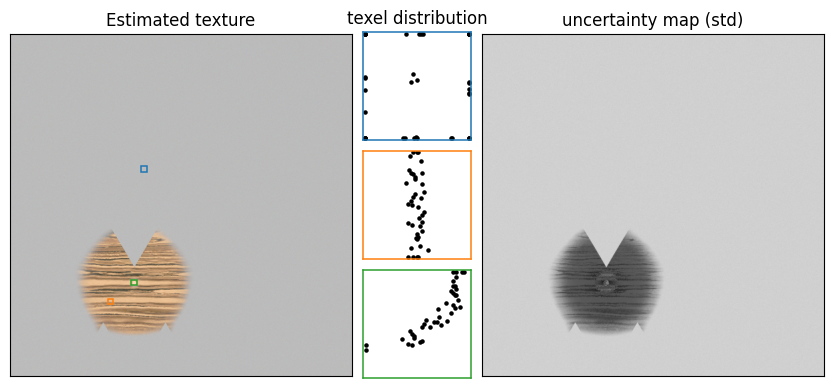

In [42]:
from vis import plot_texture_samples, animate_particles
plot_texture_samples(x, [(202,200),(400,150),(372,185)])

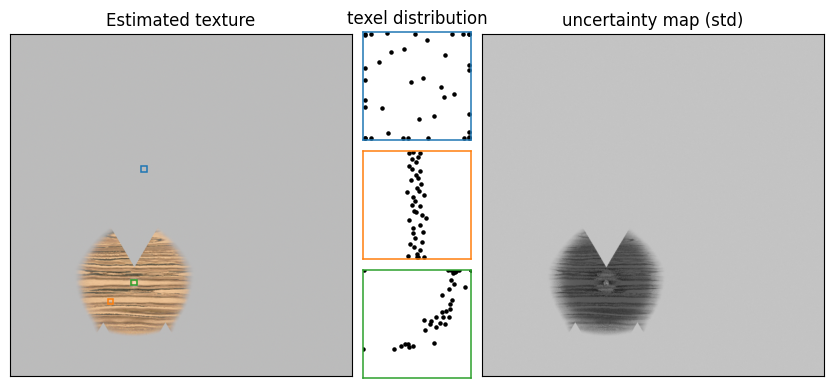

In [43]:

plot_texture_samples(x_laplace, [(202,200),(400,150),(372,185)])

In [44]:
s = torch.stack(snapshots, axis=0)
animate_particles(s[:,:,0,47,1::2], title='SVGD particles')

In [45]:
s = torch.stack(snapshots, axis=0)
animate_particles(s[:,:,0,35,1::2], title='SVGD particles')

In [65]:
%matplotlib notebook
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10,100)

def f(x, A, B, C):
    return A*x**2 + B*x + C

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
line, = ax.plot(x, f(x, A=1, B=1, C=1))

def update(A = 1, B = 0, C = 0):
    line.set_ydata(f(x,A,B,C))
    fig.canvas.draw_idle()
    
interact(update, A = (-4,4,0.1), B = (-4,4,0.1), C = (-4,4,0.1));

<IPython.core.display.Javascript object>

interactive(children=(FloatSlider(value=1.0, description='A', max=4.0, min=-4.0), FloatSlider(value=0.0, descr…

In [69]:
!nbextension list

'nbextension' is not recognized as an internal or external command,
operable program or batch file.
